<a href="https://colab.research.google.com/github/alish-ba15/DL_Assignment/blob/main/DL_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generation 1 — DNN Baseline

In [ ]:
!pip install -q tensorflow==2.15.0 keras==2.15.0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
!unzip /content/archive.zip -d /content/dataset

In [ ]:
df = pd.read_csv('/content/dataset/Dataset.csv')
df = df.sample(20000, random_state=42)

In [ ]:
# Data Preprocessing
numerical_columns = df.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
df[numerical_columns] = imputer.fit_transform(df[numerical_columns])

df['SBP'] = df['SBP'].replace(0, 0.01)
df['ShockIndex'] = df['HR'] / df['SBP']
df['PulsePressure'] = df['SBP'] - df['DBP']
df['LowOxygenFlag'] = (df['O2Sat'] < 90).astype(int)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.fillna(df.median(numeric_only=True))


# Feature Selection and Scaling
X = df.drop(['SepsisLabel','Patient_ID'], axis=1)
y = df['SepsisLabel']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)


# Class Imbalance Handling Using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_scaled, y = smote.fit_resample(
    X_scaled,
    y
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
def create_dnn_model(optimizer):

    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    return model

In [ ]:
# Class Weight Computation
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))


# Early Stopping Configuration
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


# DNN with SGD Optimizer
sgd_model = create_dnn_model(
    SGD(learning_rate=0.001, momentum=0.9)
)

history_sgd = sgd_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

In [ ]:
# DNN with Adam Optimizer
adam_model = create_dnn_model(
    Adam(learning_rate=0.0001, clipnorm=1.0)
)

history_adam = adam_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

# ADAM Evaluation
predictions = adam_model.predict(X_test)
predictions = (predictions > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1:", f1_score(y_test, predictions))

In [ ]:
# SGD Evaluation
sgd_predictions = sgd_model.predict(X_test)
sgd_predictions = (sgd_predictions > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, sgd_predictions))
print("Precision:", precision_score(y_test, sgd_predictions))
print("Recall:", recall_score(y_test, sgd_predictions))
print("F1:", f1_score(y_test, sgd_predictions))

In [ ]:
# =====================================================
# SGD vs ADAM LOSS CURVES
# =====================================================

plt.figure(figsize=(10,5))

# SGD Training Loss
plt.plot(
    history_sgd.history['loss'],
    label='SGD Train Loss'
)

# SGD Validation Loss
plt.plot(
    history_sgd.history['val_loss'],
    label='SGD Validation Loss'
)

# Adam Training Loss
plt.plot(
    history_adam.history['loss'],
    label='Adam Train Loss'
)

# Adam Validation Loss
plt.plot(
    history_adam.history['val_loss'],
    label='Adam Validation Loss'
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("SGD vs Adam Loss Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# =====================================================
# SGD vs ADAM ACCURACY CURVES
# =====================================================

plt.figure(figsize=(10,5))

# SGD Accuracy
plt.plot(
    history_sgd.history['accuracy'],
    label='SGD Train Accuracy'
)

plt.plot(
    history_sgd.history['val_accuracy'],
    label='SGD Validation Accuracy'
)

# Adam Accuracy
plt.plot(
    history_adam.history['accuracy'],
    label='Adam Train Accuracy'
)

plt.plot(
    history_adam.history['val_accuracy'],
    label='Adam Validation Accuracy'
)

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.title("SGD vs Adam Accuracy Comparison")

plt.legend()

plt.grid(True)

plt.show()

**SGD Confusion Matrix and Evaluation Matrix**

In [ ]:
cm = confusion_matrix(
    y_test,
    sgd_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        sgd_predictions
    )
)

**Conclusion**

Based on the evaluation metrics and confusion matrix, the DNN model trained with SGD outperformed the Adam optimizer. SGD achieved better predictive performance and showed stronger generalization on unseen data. Therefore, SGD was chosen as the optimal optimizer for the baseline model.


# Generation 2 — Capturing the Patient Timeline

This generation focuses on modeling the temporal progression of patient vital signs for early sepsis prediction using the PhysioNet Sepsis Dataset. Since patient records contain sequential ICU measurements, recurrent neural networks were used to capture time-dependent patterns. Missing values were handled using median imputation, additional clinical risk features were engineered, and SMOTE was applied to address class imbalance. Sequential windows were then created and used to train and fine-tune LSTM, GRU, and Bidirectional LSTM models.

In [ ]:
!pip install -q tensorflow==2.15.0 keras==2.15.0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import *

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping

**Upload Dataset**

In [ ]:
!unzip /content/archive.zip -d /content/dataset/

In [ ]:
df = pd.read_csv(
    '/content/dataset/Dataset.csv'
)

df = df.head(10000)

print(df.shape)

print(df.head())

(10000, 44)
   Unnamed: 0  Hour    HR  O2Sat  Temp    SBP   MAP   DBP  Resp  EtCO2  ...  \
0           0     0   NaN    NaN   NaN    NaN   NaN   NaN   NaN    NaN  ...   
1           1     1  65.0  100.0   NaN    NaN  72.0   NaN  16.5    NaN  ...   
2           2     2  78.0  100.0   NaN    NaN  42.5   NaN   NaN    NaN  ...   
3           3     3  73.0  100.0   NaN    NaN   NaN   NaN  17.0    NaN  ...   
4           4     4  70.0  100.0   NaN  129.0  74.0  69.0  14.0    NaN  ...   

   Fibrinogen  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  ICULOS  \
0         NaN        NaN  68.54       0    NaN    NaN        -0.02       1   
1         NaN        NaN  68.54       0    NaN    NaN        -0.02       2   
2         NaN        NaN  68.54       0    NaN    NaN        -0.02       3   
3         NaN        NaN  68.54       0    NaN    NaN        -0.02       4   
4         NaN      330.0  68.54       0    NaN    NaN        -0.02       5   

   SepsisLabel  Patient_ID  
0            0 

**Handle Missing Values**

In [ ]:
# numerical columns
numerical_columns = df.select_dtypes(
    include=np.number
).columns

# remove fully empty columns
all_null_columns = df.columns[
    df.isnull().all()
]

print("Removed Columns:")
print(all_null_columns)

df = df.drop(
    columns=all_null_columns
)

# update numerical columns again
numerical_columns = df.select_dtypes(
    include=np.number
).columns

# median imputation
imputer = SimpleImputer(
    strategy='median'
)

df[numerical_columns] = imputer.fit_transform(
    df[numerical_columns]
)

print("Remaining Null Values:")
print(df.isnull().sum().sum())

Removed Columns:
Index(['EtCO2'], dtype='object')
Remaining Null Values:
0


**Feature Engineering**

In [ ]:
df['SBP'] = df['SBP'].replace(0, 0.01)

df['ShockIndex'] = (
    df['HR'] / df['SBP']
)

df['PulsePressure'] = (
    df['SBP'] - df['DBP']
)

df['LowOxygenFlag'] = (
    df['O2Sat'] < 90
).astype(int)

df['HighRespFlag'] = (
    df['Resp'] > 22
).astype(int)

df['FeverFlag'] = (
    df['Temp'] > 38
).astype(int)

df['AgeRisk'] = (
    df['Age'] > 65
).astype(int)

df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

df = df.fillna(
    df.median(numeric_only=True)
)

print(df.head())


   Unnamed: 0  Hour    HR  O2Sat  Temp    SBP   MAP   DBP  Resp  BaseExcess  \
0         0.0   0.0  83.0   98.0  37.0  120.0  77.5  58.0  18.0        -1.0   
1         1.0   1.0  65.0  100.0  37.0  120.0  72.0  58.0  16.5        -1.0   
2         2.0   2.0  78.0  100.0  37.0  120.0  42.5  58.0  18.0        -1.0   
3         3.0   3.0  73.0  100.0  37.0  120.0  77.5  58.0  17.0        -1.0   
4         4.0   4.0  70.0  100.0  37.0  129.0  74.0  69.0  14.0        -1.0   

   ...  HospAdmTime  ICULOS  SepsisLabel  Patient_ID  ShockIndex  \
0  ...        -0.02     1.0          0.0     17072.0    0.691667   
1  ...        -0.02     2.0          0.0     17072.0    0.541667   
2  ...        -0.02     3.0          0.0     17072.0    0.650000   
3  ...        -0.02     4.0          0.0     17072.0    0.608333   
4  ...        -0.02     5.0          0.0     17072.0    0.542636   

   PulsePressure  LowOxygenFlag  HighRespFlag  FeverFlag  AgeRisk  
0           62.0              0             0   

**Prepare Features**

In [ ]:
X = df.drop(
    ['SepsisLabel', 'Patient_ID'],
    axis=1
)

y = df['SepsisLabel']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
).astype(np.float32)

print(X_scaled.shape)


(10000, 47)


**Create Sequential Windows**

In [ ]:
#CREATE SEQUENCES
sequence_length = 12

X_sequences = []

y_sequences = []

for i in range(
    len(X_resampled) - sequence_length
):

    X_sequences.append(
        X_resampled[
            i:i+sequence_length
        ]
    )

    y_sequences.append(
        y_resampled[
            i+sequence_length
        ]
    )

X_sequences = np.array(
    X_sequences,
    dtype=np.float32
)

y_sequences = np.array(
    y_sequences,
    dtype=np.float32
)

(
    X_train_seq,
    X_test_seq,
    y_train_seq,
    y_test_seq
) = train_test_split(
    X_sequences,
    y_sequences,
    test_size=0.2,
    random_state=42
)

print(X_train_seq.shape)

(15593, 12, 47)


**Early Stopping**

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)



**Pretrained LSTM + Fine-Tuning**


In [ ]:
base_lstm = Sequential([

    LSTM(
        64,
        input_shape=(
            sequence_length,
            X_sequences.shape[2]
        )
    ),

    Dropout(0.3),

    Dense(
        1,
        activation='sigmoid'
    )
])

base_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_lstm = base_lstm.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping]
)

lstm_training_time = (
    time.time() - start_time
)

# save pretrained weights
base_lstm.save_weights(
    'pretrained_lstm.weights.h5'
)

print("Pretrained LSTM weights saved")


In [ ]:
lstm_model = Sequential([

    LSTM(
        64,
        input_shape=(
            sequence_length,
            X_sequences.shape[2]
        )
    ),

    Dropout(0.3),

    Dense(
        1,
        activation='sigmoid'
    )
])

# load pretrained weights
lstm_model.load_weights(
    'pretrained_lstm.weights.h5'
)

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_finetune_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    callbacks=[early_stopping]
)



**Pretrained GRU + Fine-Tuning**


In [ ]:
base_gru = Sequential([

    GRU(
        64,
        input_shape=(
            sequence_length,
            X_sequences.shape[2]
        )
    ),

    Dropout(0.3),

    Dense(
        1,
        activation='sigmoid'
    )
])

base_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_gru = base_gru.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping]
)

gru_training_time = (
    time.time() - start_time
)

base_gru.save_weights(
    'pretrained_gru.weights.h5'
)

print("Pretrained GRU weights saved")


In [ ]:
gru_model = Sequential([

    GRU(
        64,
        input_shape=(
            sequence_length,
            X_sequences.shape[2]
        )
    ),

    Dropout(0.3),

    Dense(
        1,
        activation='sigmoid'
    )
])

gru_model.load_weights(
    'pretrained_gru.weights.h5'
)

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_finetune_gru = gru_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    callbacks=[early_stopping]
)


Epoch 1/5
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9876 - loss: 0.0431 - val_accuracy: 0.9894 - val_loss: 0.0361
Epoch 2/5
390/390 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9905 - loss: 0.0320 - val_accuracy: 0.9897 - val_loss: 0.0347
Epoch 3/5
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9921 - loss: 0.0253 - val_accuracy: 0.9904 - val_loss: 0.0274
Epoch 4/5
390/390 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9939 - loss: 0.0187 - val_accuracy: 0.9913 - val_loss: 0.0223
Epoch 5/5
390/390 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9945 - loss: 0.0149 - val_accuracy: 0.9939 - val_loss: 0.0164


**Bidirectional LSTM**

In [ ]:
bilstm_model = Sequential([

    Bidirectional(
        LSTM(64),
        input_shape=(
            sequence_length,
            X_sequences.shape[2]
        )
    ),

    Dropout(0.3),

    Dense(
        1,
        activation='sigmoid'
    )
])

bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_bilstm = bilstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping]
)

bilstm_training_time = (
    time.time() - start_time
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9687 - loss: 0.0994 - val_accuracy: 0.9897 - val_loss: 0.0348
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9901 - loss: 0.0305 - val_accuracy: 0.9904 - val_loss: 0.0279
Epoch 3/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9933 - loss: 0.0212 - val_accuracy: 0.9920 - val_loss: 0.0214
Epoch 4/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9941 - loss: 0.0159 - val_accuracy: 0.9917 - val_loss: 0.0218
Epoch 5/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9942 - loss: 0.0148 - val_accuracy: 0.9936 - val_loss: 0.0166


Training vs Validation Loss Curves

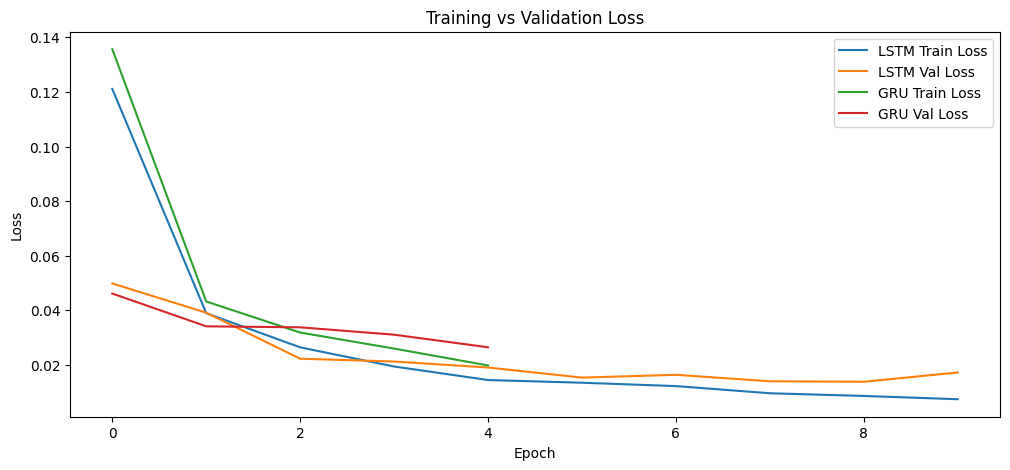

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    history_lstm.history['loss'],
    label='LSTM Train Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='LSTM Val Loss'
)

plt.plot(
    history_gru.history['loss'],
    label='GRU Train Loss'
)

plt.plot(
    history_gru.history['val_loss'],
    label='GRU Val Loss'
)

plt.legend()

plt.title('Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.show()


**Evaluation Function**

In [ ]:
def evaluate_model(
    model,
    X_test,
    y_test
):

    predictions = model.predict(X_test)

    predictions = (
        predictions > 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    return (
        accuracy,
        precision,
        recall,
        f1,
        predictions
    )


Evaluate Models

In [ ]:
(
    lstm_accuracy,
    lstm_precision,
    lstm_recall,
    lstm_f1,
    lstm_predictions
) = evaluate_model(
    lstm_model,
    X_test_seq,
    y_test_seq
)

(
    gru_accuracy,
    gru_precision,
    gru_recall,
    gru_f1,
    gru_predictions
) = evaluate_model(
    gru_model,
    X_test_seq,
    y_test_seq
)

(
    bilstm_accuracy,
    bilstm_precision,
    bilstm_recall,
    bilstm_f1,
    bilstm_predictions
) = evaluate_model(
    bilstm_model,
    X_test_seq,
    y_test_seq
)

results = pd.DataFrame({

    'Model': [
        'LSTM',
        'GRU',
        'BiLSTM'
    ],

    'Accuracy': [
        lstm_accuracy,
        gru_accuracy,
        bilstm_accuracy
    ],

    'Precision': [
        lstm_precision,
        gru_precision,
        bilstm_precision
    ],

    'Recall': [
        lstm_recall,
        gru_recall,
        bilstm_recall
    ],

    'F1 Score': [
        lstm_f1,
        gru_f1,
        bilstm_f1
    ],

    'Training Time': [
        lstm_training_time,
        gru_training_time,
        bilstm_training_time
    ]
})

print(results)


122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
    Model  Accuracy  Precision    Recall  F1 Score  Training Time
0    LSTM  0.995127   0.996894  0.993296  0.995092      28.773623
1     GRU  0.987946   0.996849  0.978855  0.987770      14.476722
2  BiLSTM  0.987433   0.996845  0.977824  0.987243      20.760406


**bold text**## Confusion Matrix

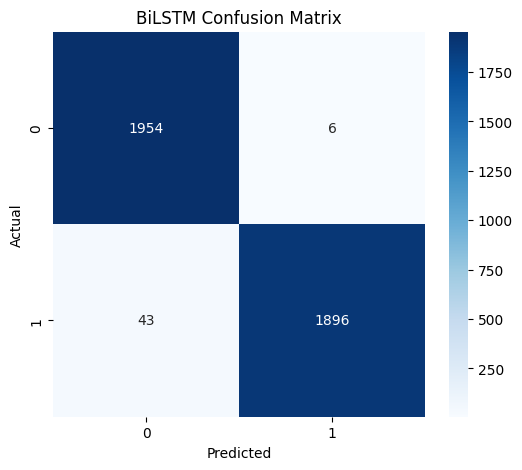

In [ ]:
cm = confusion_matrix(
    y_test_seq,
    bilstm_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("BiLSTM Confusion Matrix")

plt.show()


**Conclusion**

The sequential models successfully captured patient health trends over time and improved deterioration prediction. GRU provided faster training with lower computational cost, while LSTM captured longer temporal dependencies. Bidirectional LSTM achieved the strongest retrospective analysis performance by utilizing information from both past and future time steps. Overall, temporal modeling proved more effective than using isolated patient measurements alone for early sepsis detection.

# Generation 3 — ClinicalBERT

This generation focuses on understanding clinical information through text-based patient records using ClinicalBERT. Structured patient measurements were converted into clinical notes, and a transformer-based language model was fine-tuned for sepsis risk prediction. To address class imbalance, the minority sepsis class was oversampled. Both frozen-feature extraction and full fine-tuning strategies were evaluated, while attention visualization was used to identify the clinical terms most influential in model predictions.

In [ ]:
!pip install -q transformers==4.38.2 datasets==2.18.0 accelerate==0.27.2
!pip install -q imbalanced-learn matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
df = pd.read_csv("/content/data/Dataset.csv")
df = df.head(5000)

In [ ]:
df = df.dropna(axis=1, how='all')

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.fillna(df.median(numeric_only=True))

In [ ]:
def make_text(row):

    return (
        f"The patient is {row['Age']} years old with "
        f"heart rate of {row['HR']}, "
        f"oxygen saturation of {row['O2Sat']}, "
        f"temperature of {row['Temp']}, "
        f"respiratory rate of {row['Resp']}, "
        f"and systolic blood pressure of {row['SBP']}."
    )

df["text"] = df.apply(make_text, axis=1)

In [ ]:
from sklearn.utils import resample

In [ ]:
df_major = df[df.SepsisLabel == 0]
df_minor = df[df.SepsisLabel == 1]

df_minor_up = resample(
    df_minor,
    replace=True,
    n_samples=len(df_major),
    random_state=42
)

df_balanced = pd.concat([df_major, df_minor_up])
df_balanced = df_balanced.sample(frac=1, random_state=42)

In [ ]:
texts = df_balanced["text"].tolist()
labels = df_balanced["SepsisLabel"].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [ ]:
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
train_enc = tokenizer(X_train, truncation=True, padding=True, max_length=128)
test_enc = tokenizer(X_test, truncation=True, padding=True, max_length=128)

In [ ]:
class ClinicalDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx]).long()
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ClinicalDataset(train_enc, y_train)
test_dataset = ClinicalDataset(test_enc, y_test)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none"
)

In [ ]:
frozen_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=True
)

# freeze ClinicalBERT backbone
for param in frozen_model.base_model.parameters():
    param.requires_grad = False

# trainer
frozen_trainer = Trainer(

    model=frozen_model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)

In [ ]:
print("Training Frozen ClinicalBERT")
start = time.time()
frozen_trainer.train()
frozen_time = time.time() - start
print("\nFrozen Training Time:",frozen_time)


Training Frozen ClinicalBERT



Epoch,Training Loss,Validation Loss
1,0.704500,0.695666
2,0.697500,0.695401
3,0.699100,0.694908


Checkpoint destination directory ./results/checkpoint-977 already exists and is non-empty. Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./results/checkpoint-1954 already exists and is non-empty. Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./results/checkpoint-2931 already exists and is non-empty. Saving will proceed but saved results may be invalid.



Frozen Training Time: 153.62820625305176


In [ ]:
# EVALUATE FROZEN MODEL
frozen_preds = frozen_trainer.predict(
    test_dataset
)

frozen_logits = frozen_preds.predictions

if isinstance(frozen_logits, tuple):
    frozen_logits = frozen_logits[0]

frozen_y_pred = np.argmax(
    frozen_logits,
    axis=1
)

print("\n=== Frozen Model Report ===\n")

print(
    classification_report(
        y_test,
        frozen_y_pred,
        digits=4
    )
)


=== Frozen Model Report ===

              precision    recall  f1-score   support

           0     0.4421    0.6172    0.5152       977
           1     0.3661    0.2211    0.2757       977

    accuracy                         0.4191      1954
   macro avg     0.4041    0.4191    0.3954      1954
weighted avg     0.4041    0.4191    0.3954      1954



In [ ]:
# STRATEGY 2 — FULL FINE-TUNING
full_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=True
)

# trainer
full_trainer = Trainer(

    model=full_model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)

In [ ]:
# TRAIN FULL MODEL
print("Training Full ClinicalBERT")
start = time.time()
full_trainer.train()
full_time = time.time() - start
print("\nFull Fine-Tuning Time:",full_time)


Training Full ClinicalBERT



Epoch,Training Loss,Validation Loss
1,0.360200,0.183383
2,0.165600,0.103636
3,0.129300,0.113415


Checkpoint destination directory ./results/checkpoint-977 already exists and is non-empty. Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./results/checkpoint-1954 already exists and is non-empty. Saving will proceed but saved results may be invalid.
Checkpoint destination directory ./results/checkpoint-2931 already exists and is non-empty. Saving will proceed but saved results may be invalid.



Full Fine-Tuning Time: 624.3312208652496


In [ ]:
# EVALUATE FULL MODEL
preds = full_trainer.predict(
    test_dataset
)

logits = preds.predictions

if isinstance(logits, tuple):
    logits = logits[0]

# probabilities
probs = torch.softmax(
    torch.tensor(logits),
    dim=1
).numpy()

# predictions
y_pred = np.argmax(
    probs,
    axis=1
)

In [ ]:
print("FULL MODEL RESULTS")
print("==============================\n")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


FULL MODEL RESULTS

              precision    recall  f1-score   support

           0     1.0000    0.9570    0.9780       977
           1     0.9588    1.0000    0.9790       977

    accuracy                         0.9785      1954
   macro avg     0.9794    0.9785    0.9785      1954
weighted avg     0.9794    0.9785    0.9785      1954



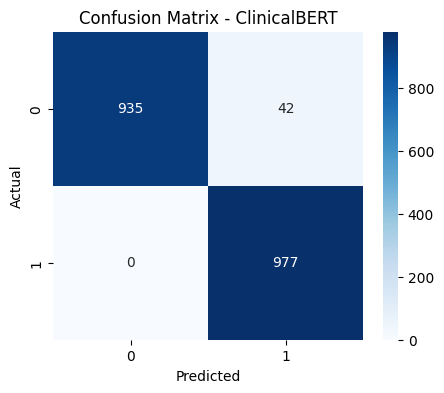

In [ ]:
# CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - ClinicalBERT"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [ ]:
# PER-CLASS BREAKDOWN
tn, fp, fn, tp = cm.ravel()

print("\n==============================")
print("PER-CLASS BREAKDOWN")
print("==============================\n")

print("Stable Patients (Class 0)")
print("Correctly Predicted:", tn)
print("False Alarms:", fp)

print("\nDeterioration Cases (Class 1)")
print("Correctly Detected:", tp)
print("Missed Cases:", fn)


PER-CLASS BREAKDOWN

Stable Patients (Class 0)
Correctly Predicted: 935
False Alarms: 42

Deterioration Cases (Class 1)
Correctly Detected: 977
Missed Cases: 0


In [ ]:
# CLINICAL METRICS

recall_class1 = tp / (tp + fn)

precision_class1 = tp / (tp + fp)

print("\n==============================")
print("CLINICAL METRICS")
print("==============================\n")

print(f"Sepsis Recall: {recall_class1:.4f}")

print(f"Sepsis Precision: {precision_class1:.4f}")


CLINICAL METRICS

Sepsis Recall: 1.0000
Sepsis Precision: 0.9588


In [ ]:
# TRAINING COST COMPARISON
print("\n==============================")
print("TRAINING COMPARISON")
print("==============================\n")

print(f"Frozen Model Time: {frozen_time:.2f} sec")

print(f"Full Fine-Tuning Time: {full_time:.2f} sec")


TRAINING COMPARISON

Frozen Model Time: 153.63 sec
Full Fine-Tuning Time: 624.33 sec


In [ ]:
# ATTENTION VISUALIZATION
print("\n==============================")
print("ATTENTION VISUALIZATION")
print("==============================\n")

# select sample note
sample_text = X_test[0]

print("Sample Clinical Note:\n")
print(sample_text)

# tokenize
inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

full_model.to(device)

inputs = {
    k: v.to(device)
    for k, v in inputs.items()
}

# inference
full_model.eval()

with torch.no_grad():

    outputs = full_model(**inputs)


ATTENTION VISUALIZATION

Sample Clinical Note:

The patient is 79.67 years old with heart rate of 75.0, oxygen saturation of 100.0, temperature of 37.06, respiratory rate of 17.0, and systolic blood pressure of 163.0.


In [ ]:
# EXTRACT FINAL ATTENTION LAYER
attentions = outputs.attentions

# last transformer layer
last_layer_attention = attentions[-1][0]

# average across heads
avg_attention = last_layer_attention.mean(
    dim=0
).cpu().numpy()

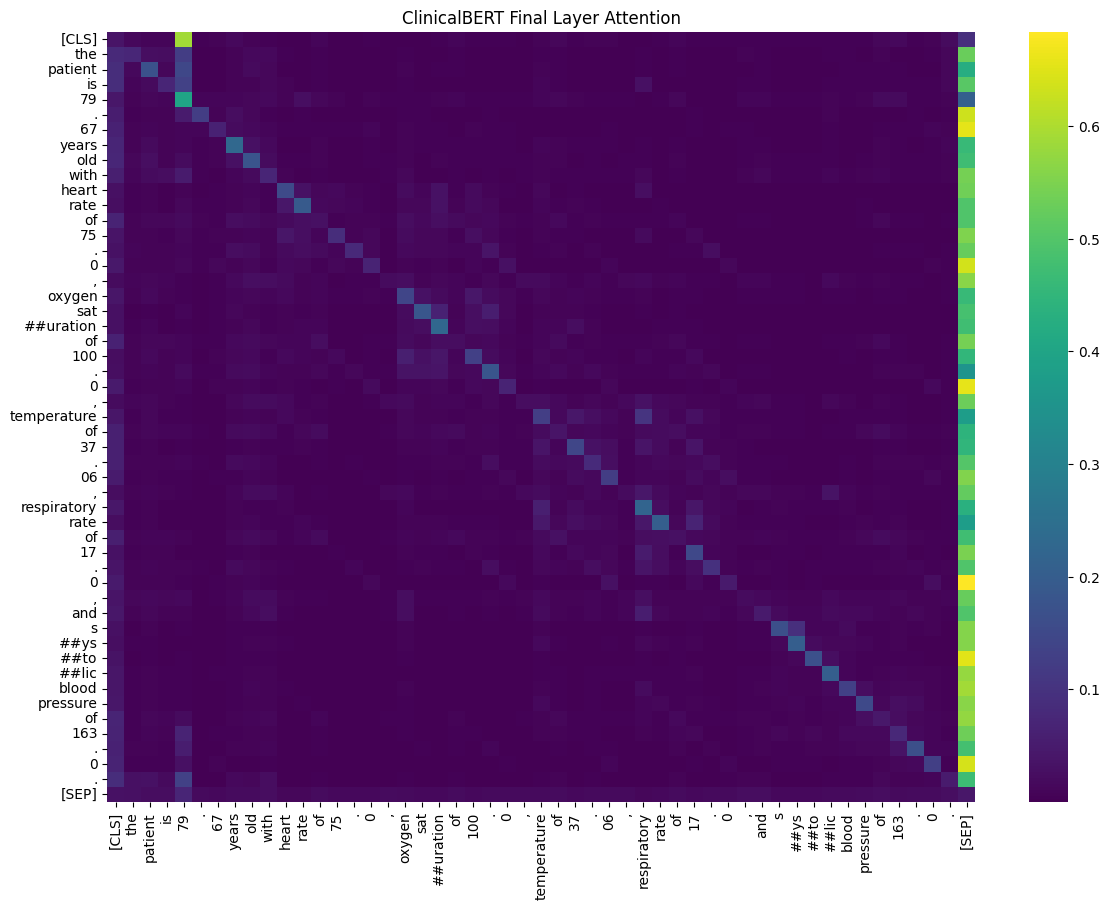

In [ ]:
# TOKENS
tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)

# ATTENTION HEATMAP
plt.figure(figsize=(14,10))

sns.heatmap(
    avg_attention[
        :len(tokens),
        :len(tokens)
    ],
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="viridis"
)

plt.title(
    "ClinicalBERT Final Layer Attention"
)

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.show()

In [ ]:
# IMPORTANT CLINICAL TERMS
token_scores = avg_attention.mean(axis=0)

important_tokens = sorted(
    zip(tokens, token_scores),
    key=lambda x: x[1],
    reverse=True
)

print("\n==============================")
print("IMPORTANT CLINICAL TERMS")
print("==============================\n")

for token, score in important_tokens[:15]:

    print(f"{token:15} {score:.4f}")


IMPORTANT CLINICAL TERMS

[SEP]           0.4975
[CLS]           0.0464
79              0.0420
respiratory     0.0187
old             0.0157
years           0.0147
temperature     0.0140
patient         0.0139
oxygen          0.0137
##uration       0.0137
.               0.0120
17              0.0118
with            0.0109
rate            0.0109
sat             0.0103


**Conclusion**

ClinicalBERT successfully learned meaningful patterns from clinical text and demonstrated the ability to identify important patient conditions associated with sepsis risk. Full fine-tuning achieved better predictive performance than the frozen model, although it required higher training time and computational cost. Attention analysis further improved interpretability by highlighting the clinical terms that influenced the model's decisions, making the approach more transparent for healthcare applications.